In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pylab as plt

In [123]:
page_time = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/web_page_data.csv")
page_time.Time *= 100
page_time

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0
5,Page B,85.0
6,Page A,211.0
7,Page B,246.0
8,Page A,132.0
9,Page B,149.0


In [124]:
groupA = page_time[page_time.Page == "Page A"].Time.mean()
groupB = page_time[page_time.Page == "Page B"].Time.mean()

In [125]:
groupB - groupA

np.float64(35.66666666666667)

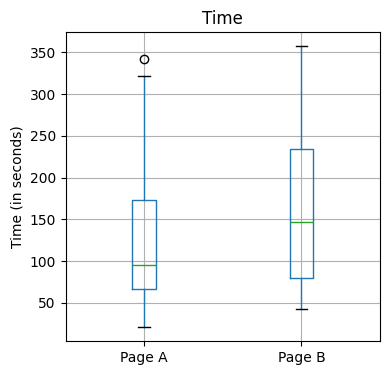

In [126]:
ax = page_time.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()


<Axes: ylabel='Frequency'>

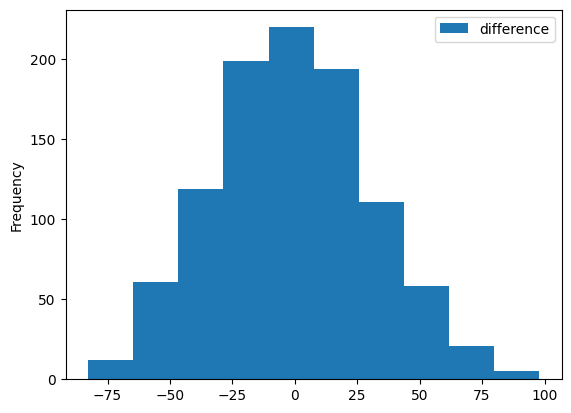

In [127]:
def permutation_func(pd_time, rows_a, rows_b):
    n = rows_a + rows_b
    idx_b = set(random.sample(range(n), rows_b))
    idx_a = set(range(n)) - idx_b
    return pd_time.loc[list(idx_b)].mean() - pd_time.loc[list(idx_a)].mean()
    
rows_a = page_time[page_time.Page == 'Page A'].shape[0]
rows_b = page_time[page_time.Page == 'Page B'].shape[0]

permutation_test = pd.DataFrame({"difference": []})
for i in range(1000):
    permutation_test.loc[len(permutation_test)] = permutation_func(page_time.Time, rows_a, rows_b)
permutation_test.plot.hist()